
<h2 style='color:blue' align='center'>Sports Celebrity Image Classification<h2>

Special thanks to codebasics youtube channel

In [4]:
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

#### When we look at any image, most of the time we identify a person using a face. An image might contain multiple faces, also the face can be obstructed and not clear. The first step in our pre-processing pipeline is to detect faces from an image. Once face is detected, we will detect eyes, if two eyes are detected then only we keep that image otherwise discard it.</h4>

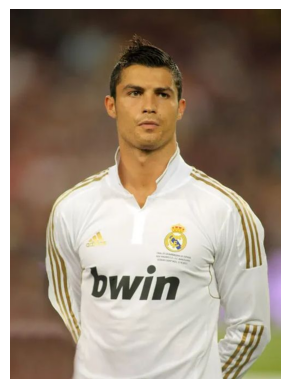

In [5]:
img = cv2.imread('./test_images/ronaldo1.jpg') 
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.axis("off")
plt.show()

In [6]:
base_options = python.BaseOptions(
    model_asset_path="face_landmarker.task"
)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=3
)
detector = vision.FaceLandmarker.create_from_options(options)

In [7]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb
)

result = detector.detect(mp_image)
result.face_landmarks

[[NormalizedLandmark(x=0.513454794883728, y=0.30249154567718506, z=-0.03130826726555824, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5165098905563354, y=0.2754824161529541, z=-0.05513755604624748, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5148932933807373, y=0.28416696190834045, z=-0.029618501663208008, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.508516788482666, y=0.25205686688423157, z=-0.040525227785110474, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5169769525527954, y=0.26789215207099915, z=-0.05802267789840698, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5170251131057739, y=0.2586502432823181, z=-0.05330018326640129, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5168504118919373, y=0.23654311895370483, z=-0.024348892271518707, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.4464244544506073, y=0.2325624227523803

In [8]:
face_img = img.copy()

if result.face_landmarks:

    h, w = img.shape[:2]
    lm = result.face_landmarks[0]

    xs = [int(p.x * w) for p in lm]
    ys = [int(p.y * h) for p in lm]

    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)

    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    LEFT_EYE = [33, 133, 160, 159, 158, 157, 173]
    RIGHT_EYE = [362, 263, 387, 386, 385, 384, 398]

    def get_eye_box(indices):
        ex = [int(lm[i].x * w) for i in indices]
        ey = [int(lm[i].y * h) for i in indices]
        return min(ex), min(ey), max(ex), max(ey)

    lx1, ly1, lx2, ly2 = get_eye_box(LEFT_EYE)
    rx1, ry1, rx2, ry2 = get_eye_box(RIGHT_EYE)

    if (lx2 - lx1 < 5 or ly2 - ly1 < 5 or
        rx2 - rx1 < 5 or ry2 - ry1 < 5):
        roi_color = None
    else:
    
        pad = 20
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(w, x2 + pad)
        y2 = min(h, y2 + pad)

     
        cv2.rectangle(face_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.rectangle(face_img, (lx1, ly1), (lx2, ly2), (0, 255, 0), 2)
        cv2.rectangle(face_img, (rx1, ry1), (rx2, ry2), (0, 255, 0), 2)

          
        roi_color = img[y1:y2, x1:x2]

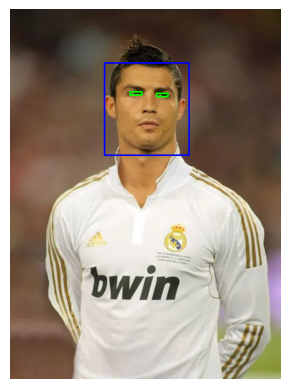

In [9]:
plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

<h3 style='color:purple'>(2) Preprocessing: Crop the facial region of the image</h3>

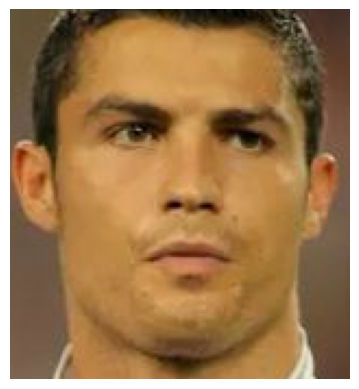

(170, 156, 3)


In [10]:
plt.imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(roi_color.shape)


In [11]:
import os
import shutil

path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"


if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)

os.makedirs(path_to_cr_data)

In [12]:
img_dirs = [
    d.path for d in os.scandir(path_to_data)
    if d.is_dir() and d.name != "cropped"
]
img_dirs

['./dataset/angelina_jolie',
 './dataset/cristiano_ronaldo',
 './dataset/elon_musk',
 './dataset/taylor_swift',
 './dataset/tom_cruise']

In [13]:
def get_cropped_face(image_path):
    import cv2
    import mediapipe as mp

    img = cv2.imread(image_path)
    if img is None:
        return None

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = detector.detect(mp_image)

    if not result.face_landmarks:
        return None

    h, w = img.shape[:2]

    LEFT_EYE = [33, 133, 160, 159, 158, 157, 173]
    RIGHT_EYE = [362, 263, 387, 386, 385, 384, 398]

    for lm in result.face_landmarks:

        left_eye = lm[33]
        right_eye = lm[263]

        x1 = left_eye.x * w
        y1 = left_eye.y * h
        x2 = right_eye.x * w
        y2 = right_eye.y * h

        dx = x2 - x1
        dy = y2 - y1

        angle = np.degrees(np.arctan2(dy, dx))

        center = ((x1 + x2) / 2, (y1 + y2) / 2)

        M = cv2.getRotationMatrix2D(center, angle, 1)

        img = cv2.warpAffine(img, M, (w, h))




        xs = [int(p.x * w) for p in lm]
        ys = [int(p.y * h) for p in lm]

        x1, y1 = max(0, min(xs)), max(0, min(ys))
        x2, y2 = min(w, max(xs)), min(h, max(ys))

        pad = 20
        x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
        x2, y2 = min(w, x2 + pad), min(h, y2 + pad)

        def get_eye_box(indices):
            ex = [int(lm[i].x * w) for i in indices]
            ey = [int(lm[i].y * h) for i in indices]
            return min(ex), min(ey), max(ex), max(ey)
        

        roi_color = img[y1:y2, x1:x2]

        if roi_color.shape[0] < 50 or roi_color.shape[1] < 50:
            continue
        
        return roi_color

    return None

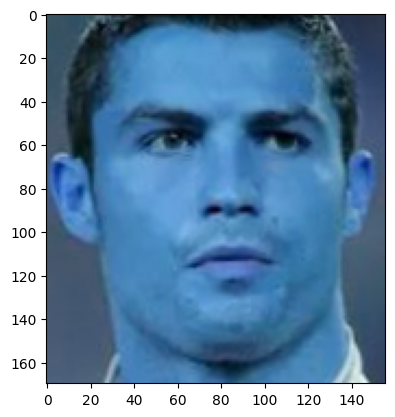

In [14]:
cropped_image = get_cropped_face('./test_images/ronaldo1.jpg')
plt.imshow(cropped_image)

<h3 style='color:purple'>(3) Preprocessing: Use wavelet transform as a feature for traning our model</h3>

### Wavelet transform

In [15]:
import pywt
import cv2
import numpy as np

def w2d(img, mode='haar', level=1):
    imArray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    imArray = np.float32(imArray)
    imArray /= 255

    coeffs = pywt.wavedec2(imArray, mode, level=level)

    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

### Now you should have cropped folder under datasets folder that contains cropped images

### Manually examine cropped folder and delete any unwanted images

In [16]:
celebrity_files = {}
for img_dir in img_dirs:

    person_name = os.path.basename(img_dir)
    celebrity_files[person_name] = []

    count = 1

    for img_file in os.scandir(img_dir):

        roi_color = get_cropped_face(img_file.path)

        if roi_color is not None:

            save_folder = os.path.join(path_to_cr_data, person_name)

            os.makedirs(save_folder, exist_ok=True)

            file_path = os.path.join(
                save_folder, f"{person_name}_{count}.jpg"
            )
    
            cv2.imwrite(file_path, roi_color)

            celebrity_files[person_name].append(file_path)

            count += 1

    print(f"{person_name} done")

angelina_jolie done
cristiano_ronaldo done
elon_musk done
taylor_swift done
tom_cruise done


In [17]:
class_dict = {}
count = 0

for name in celebrity_files.keys():
    class_dict[name] = count
    count += 1
class_dict

{'angelina_jolie': 0,
 'cristiano_ronaldo': 1,
 'elon_musk': 2,
 'taylor_swift': 3,
 'tom_cruise': 4}

### Images in cropped folder can be used for model training. We will use these raw images along with wavelet transformed images to train our classifier. Let's prepare X and y now

In [18]:
X, y = [], []

for celebrity_name, training_files in celebrity_files.items():
    for training_image in training_files:

        img = cv2.imread(training_image)

        if img is None:
            continue

        scalled_raw_img = cv2.resize(img, (64, 64))

        img_har = w2d(img, 'db1', 2)
        scalled_img_har = cv2.resize(img_har, (64, 64))

        combined_img = np.concatenate((
            scalled_raw_img.flatten(),
            scalled_img_har.flatten()
        ))

        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [19]:
len(X[0])

16384

In [20]:
32*32*3 + 32*32

4096

In [21]:
len(X)

1046

In [22]:
# X = np.array(X).reshape(len(X), 4096).astype(float)
# X.shape

X = np.array(X, dtype=object)


### Data cleaning process is done. Now we are ready to train our model

We will use SVM with rbf kernel tuned  with heuristic finetuning

In [24]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0)

pipe = Pipeline([('scalar', StandardScaler()), ('svc', SVC(kernel='rbf', C= 10, probability=True))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.9236641221374046

In [26]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        39
           1       0.88      0.90      0.89        51
           2       0.91      0.91      0.91        53
           3       1.00      0.97      0.98        66
           4       0.89      0.89      0.89        53

    accuracy                           0.92       262
   macro avg       0.92      0.92      0.92       262
weighted avg       0.92      0.92      0.92       262



### Let's use GridSearch to try out different models with different paramets. Goal is to come up with best modle with best fine tuned parameters

In [27]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [28]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='scale', probability= True),
        'params' : {
            'svc__C': [1,10],
            'svc__kernel': ['rbf']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='lbfgs', max_iter=1000),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [30]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'],cv=3, n_jobs=-1, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.918385,"{'svc__C': 10, 'svc__kernel': 'rbf'}"
1,random_forest,0.770417,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.920954,{'logisticregression__C': 1}


In [31]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc', SVC(C=10, probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression', LogisticRegression(C=1, max_iter=1000))])}

In [32]:
best_estimators['svm'].score(X_test, y_test)

0.9236641221374046

In [33]:
best_estimators['random_forest'].score(X_test, y_test)

0.8320610687022901

In [34]:
best_estimators['logistic_regression'].score(X_test, y_test)

0.9580152671755725

In [35]:
best_clf = best_estimators['svm']

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[37,  1,  1,  0,  0],
       [ 1, 46,  1,  0,  3],
       [ 0,  3, 48,  0,  2],
       [ 1,  0,  0, 64,  1],
       [ 1,  2,  3,  0, 47]])

Text(95.72222222222221, 0.5, 'Truth')

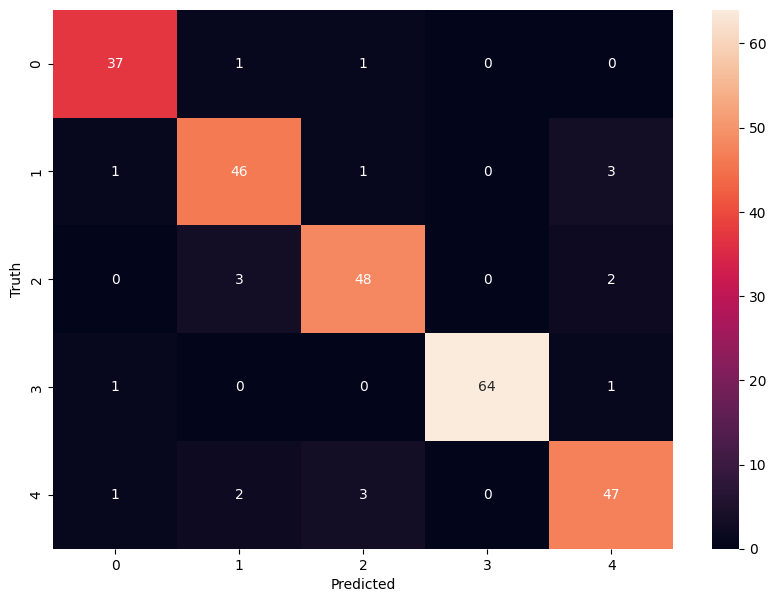

In [38]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

### Save the trained model

In [41]:
import joblib 
# Save the model as a pickle in a file 
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

### Save class dictionary

In [42]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))